In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [79]:
DATA_DIR = '../data/raw/'
df = pd.read_csv(DATA_DIR+'raw_data.csv')

Ideas de nuevas features?

- Igual sacar alguna variable que relacione el slope con el elevation. Que igual no es lo mismo que un bosque esté a 3000 metros y plano que otro a 3000 y con inclinación (ni idea hay que indagar)
- He visto que el Aspect es como la orientación hacia la que está orientada la pendiente del terreno en grados azimuth. 
    -  (según lo que he entendido es como las direcciones de una brújula)

- Podemos probar a agrupar los soil types. (rollo viendo más o menos en que tipo de bosques se presentan más, igual podemos deducir)
- Hacer PCA para reducir dimensiones sobre todo por los soil types,...
- Quitar las features correlacionadas

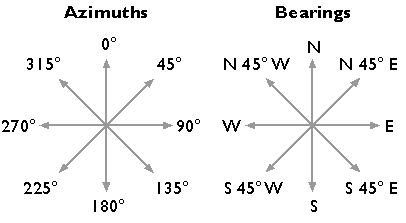

# Feature Engineering

## Creating Features 

In this section, we will be creating some features from the already existing ones. This can help us capture more information from the data. Some of these new features will be related to distances, Hillshade and Orientation & Topology

In [80]:
def get_cardinal_direction(aspect):
    if aspect < 45 or aspect >= 315:
        return 'N'
    elif 45 <= aspect < 135:
        return 'E'
    elif 135 <= aspect < 225:
        return 'S'
    else:
        return 'W'

In [81]:
# DISTANCE FEATURES

# Euclidean distance
df['Euclidean_Distance_To_Hydrology'] = np.sqrt(
    df['Horizontal_Distance_To_Hydrology']**2 +
    df['Vertical_Distance_To_Hydrology']**2
)

# Ratios
df['Distance_To_Hydrology_To_Roadways_Ratio'] = (
    df['Horizontal_Distance_To_Hydrology'] / 
    df['Horizontal_Distance_To_Roadways'] + 1
)

df['Distance_To_Fire_To_Hydrology_Ratio'] = (
    df['Horizontal_Distance_To_Fire_Points'] / 
    (df['Horizontal_Distance_To_Hydrology'] + 1)
)

# Total distance
df['Total_Distance'] = (
    df['Horizontal_Distance_To_Hydrology'] + 
    df['Horizontal_Distance_To_Roadways'] + 
    df['Horizontal_Distance_To_Fire_Points']
)

# Slope of the terrain to the Hydrology
df['Hydrology_Slope'] = np.arctan(
    df['Vertical_Distance_To_Hydrology']/
    (df['Horizontal_Distance_To_Hydrology'] + 1)
) * (180/np.pi)

# LIGHTING FEATURES
df['Mean_Hillshade'] = (
    df['Hillshade_9am'] +
    df['Hillshade_3pm'] + 
    df['Hillshade_Noon']
) / 3

df['Hillshade_Variance'] = df[['Hillshade_9am', 'Hillshade_3pm', 'Hillshade_Noon']].var(axis=1)

df['Hillshade_Range'] = (
    df[['Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm']].max(axis=1) - 
    df[['Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm']].min(axis=1)
)

# AGGREGATED CATEGORICAL FEATURES
wilderness_cols = [col for col in df.columns if 'Wilderness_Area' in col]
df['Wilderness_Count'] = df[wilderness_cols].sum(axis=1)

soil_cols = [col for col in df.columns if 'Soil_Type' in col]
df['Soil_Count'] = df[soil_cols].sum(axis=1)

# ORIENTATION & TOPOLOGY
df['Aspect_North_South'] = np.cos(df['Aspect'] * np.pi / 180)
df['Aspect_East_West'] = np.sin(df['Aspect'] * np.pi / 180)

# INTERACTION FEATURES
df['Elevation_Slope_Interaction'] = df['Elevation'] * df['Slope']

df['Aspect_Cardinal'] = df['Aspect'].apply(get_cardinal_direction)

### Distribution of the new numerical features

In [82]:
new_numerical_features = [
    'Elevation_Slope_Interaction', 'Hillshade_Range', 
    'Mean_Hillshade', 'Hillshade_Variance','Hydrology_Slope', 
    'Total_Distance', 'Distance_To_Fire_To_Hydrology_Ratio',
    'Distance_To_Hydrology_To_Roadways_Ratio',
    'Euclidean_Distance_To_Hydrology' ]

c:\Users\eguil\miniconda3\envs\AML\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


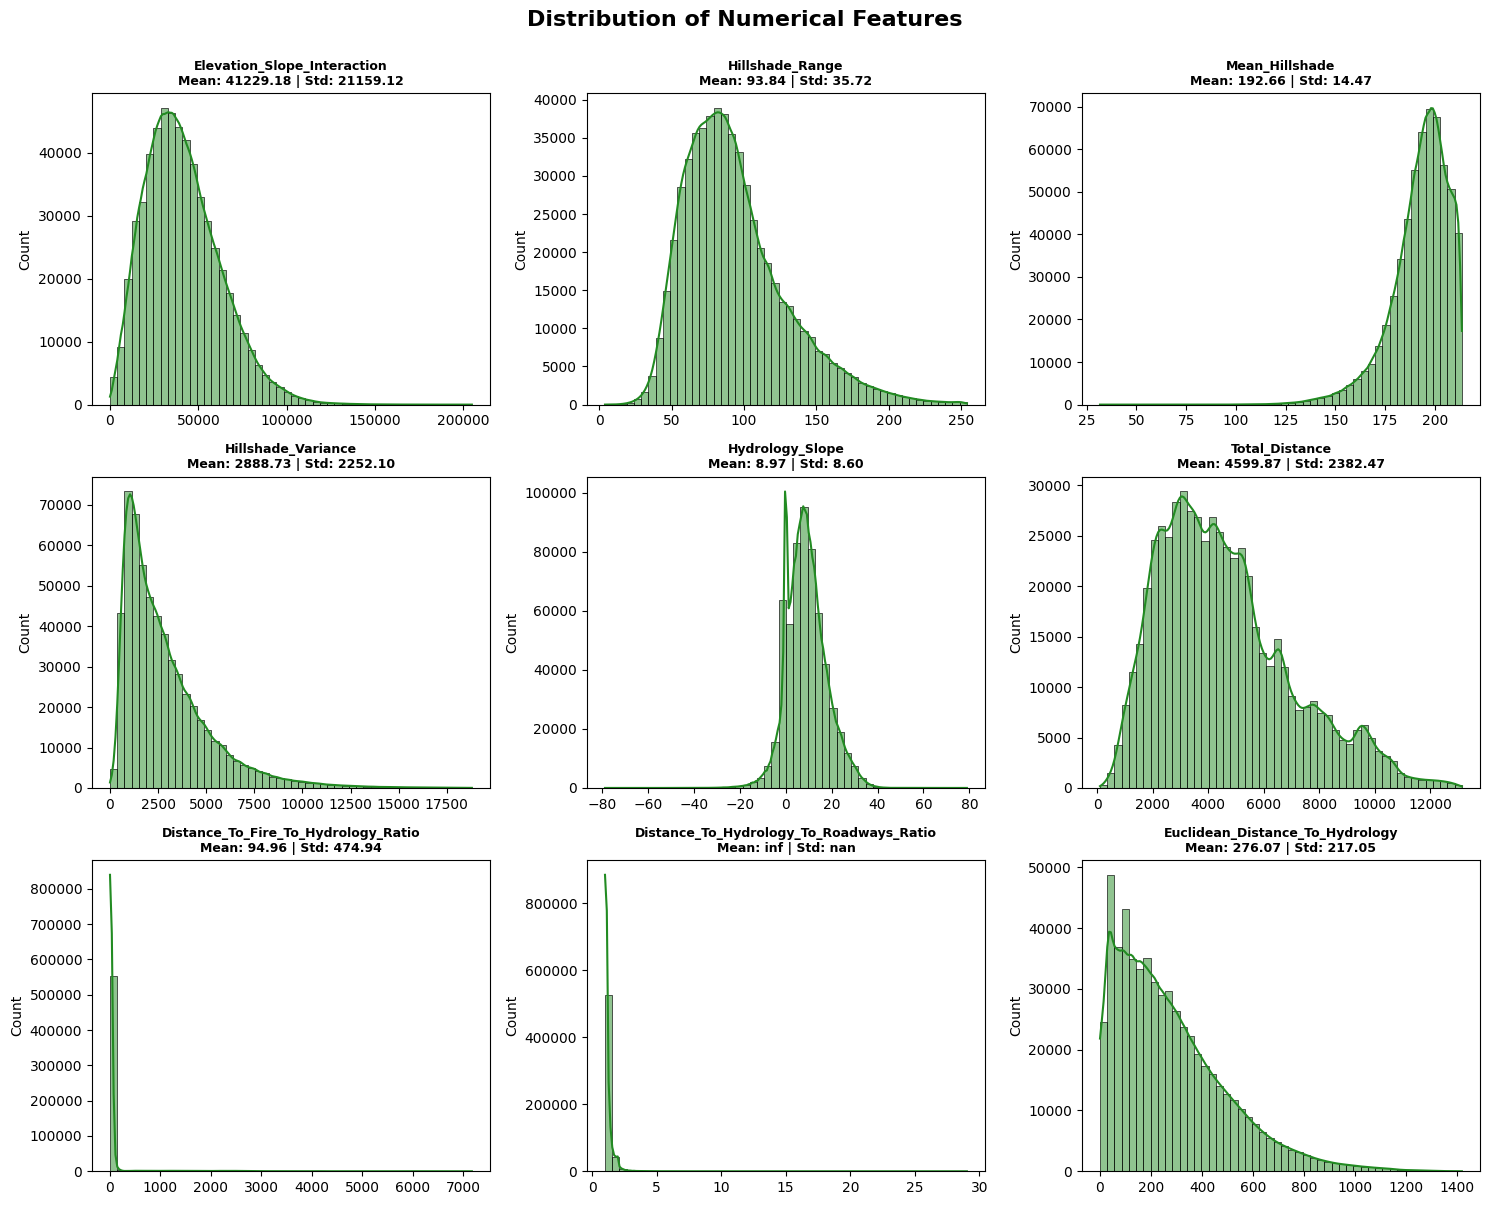

In [83]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(new_numerical_features):
    sns.histplot(df[col], bins=50, kde=True, color='forestgreen', ax=axes[idx])
    axes[idx].set_title(f'{col}\nMean: {df[col].mean():.2f} | Std: {df[col].std():.2f}', 
                       fontsize=9, fontweight='bold')
    axes[idx].set_xlabel('')

for idx in range(len(new_numerical_features), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [84]:
left_skewed_features = ['Hillshade_9am', 'Hillshade_Noon',
                        'Elevation', 'Hillshade_3pm', 'Hydrology_Slope',
                        'Mean_Hillshade']

right_skewed_features = [
    'Euclidean_Distance_To_Hydrology', 'Hillshade_Variance',
    'Total_Distance', 'Elevation_Slope_Interaction', 'Hillshade_Range',
    'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways'
]

print("Skewness before transformation")
for feature in left_skewed_features:
    skew_value = df[feature].skew()
    print(f"{feature}: {skew_value:.3f}")

Skewness before transformation
Hillshade_9am: -1.181
Hillshade_Noon: -1.063
Elevation: -0.818
Hillshade_3pm: -0.277
Hydrology_Slope: 0.280
Mean_Hillshade: -1.290


As we can see in this quick check, new variables are also skewed. We will correct this skewness in the following section.

## Normalizing distributions

To correct right skewness we will use the Logarithmic Transformation

In [85]:
from sklearn.preprocessing import PowerTransformer

# Features con skewness
left_skewed_features = ['Hillshade_9am', 'Hillshade_Noon',
                        'Elevation', 'Hillshade_3pm', 'Mean_Hillshade']

all_skewed = left_skewed_features + right_skewed_features

print("Skewness before transformation:")
for feature in all_skewed:
    print(f"{feature}: {df[feature].skew():.3f}")

# Yeo-Johnson maneja automáticamente left y right skewness
pt = PowerTransformer(method='yeo-johnson', standardize=False)

for feature in all_skewed:
    df[feature] = pt.fit_transform(df[[feature]])

print("\nSkewness after transformation:")
for feature in all_skewed:
    print(f"{feature}: {df[feature].skew():.3f}")

Skewness before transformation:
Hillshade_9am: -1.181
Hillshade_Noon: -1.063
Elevation: -0.818
Hillshade_3pm: -0.277
Mean_Hillshade: -1.290
Euclidean_Distance_To_Hydrology: 1.133
Hillshade_Variance: 1.808
Total_Distance: 0.805
Elevation_Slope_Interaction: 0.726
Hillshade_Range: 1.040
Slope: 0.789
Horizontal_Distance_To_Hydrology: 1.140
Vertical_Distance_To_Hydrology: 1.790
Horizontal_Distance_To_Roadways: 0.714

Skewness after transformation:
Hillshade_9am: -0.147
Hillshade_Noon: -0.080
Elevation: -0.036
Hillshade_3pm: -0.028
Mean_Hillshade: -0.114
Euclidean_Distance_To_Hydrology: -0.107
Hillshade_Variance: -0.005
Total_Distance: -0.020
Elevation_Slope_Interaction: -0.019
Hillshade_Range: 0.000
Slope: -0.014
Horizontal_Distance_To_Hydrology: -0.104
Vertical_Distance_To_Hydrology: 0.332
Horizontal_Distance_To_Roadways: -0.071


We see here that, after applying the Yeo-Johnson method to the numerical variables we correct the skewness.

### Corrected Feature distributions

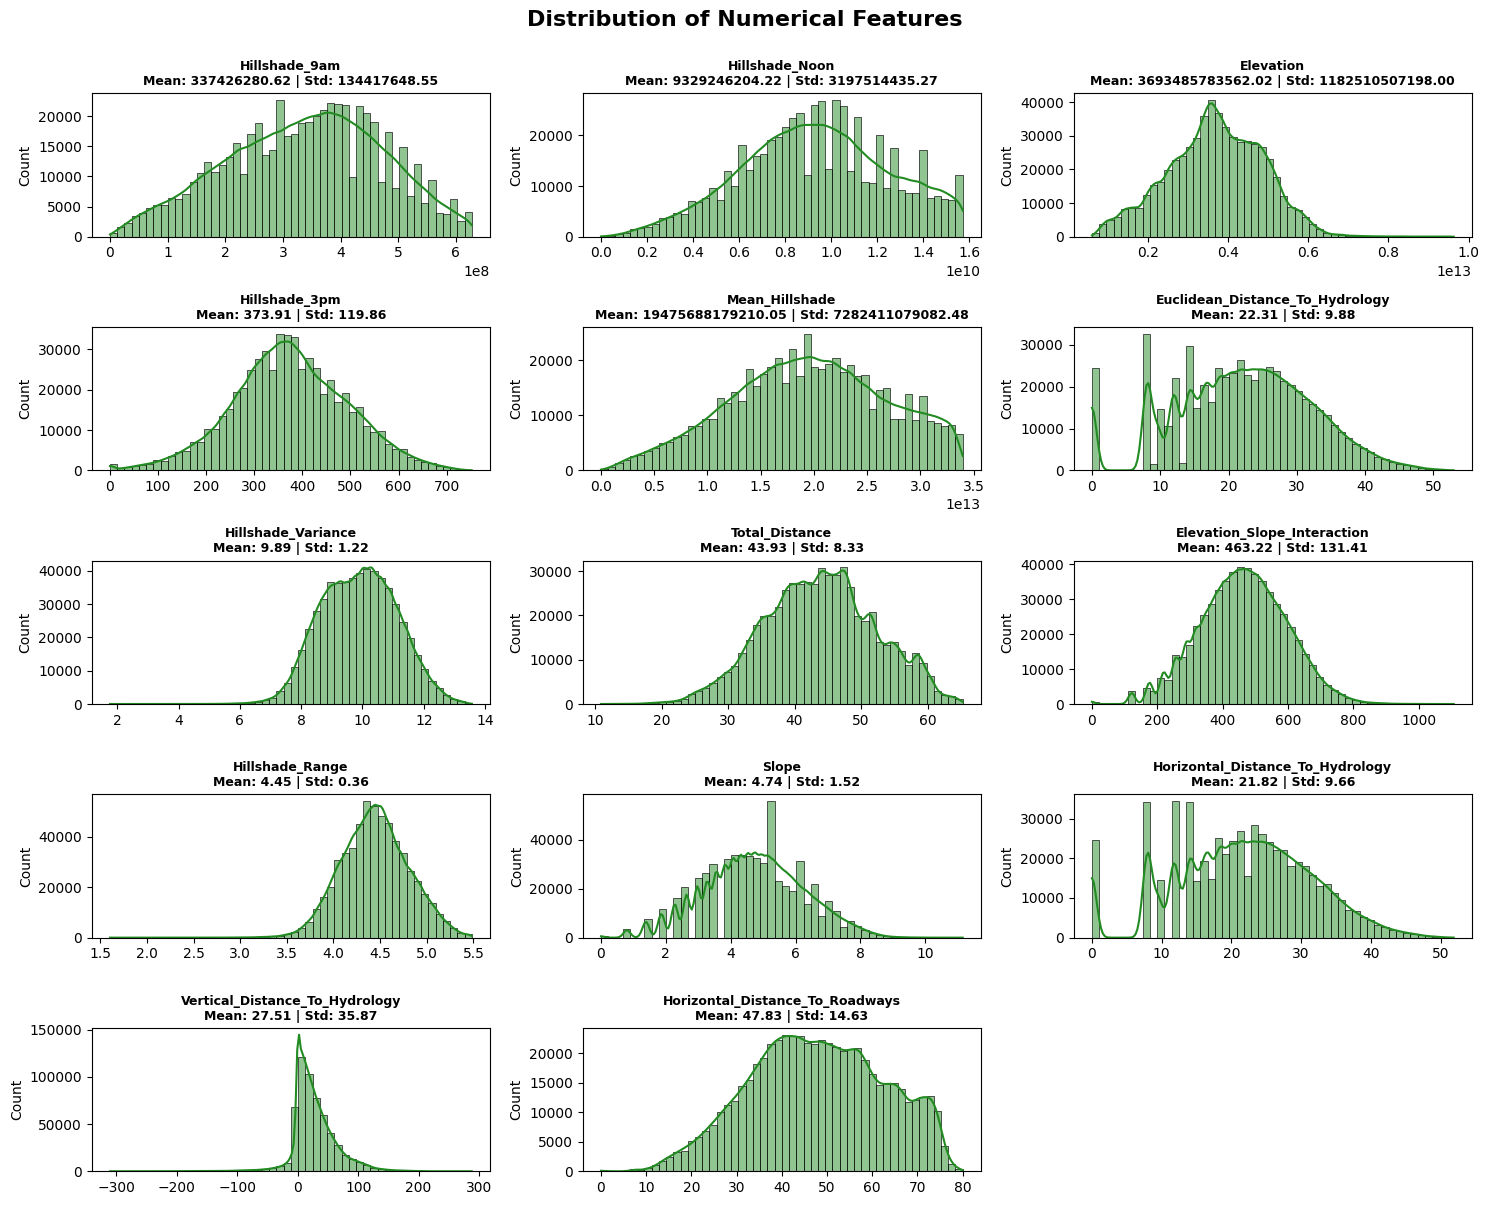

In [88]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(all_skewed):
    sns.histplot(df[col], bins=50, kde=True, color='forestgreen', ax=axes[idx])
    axes[idx].set_title(f'{col}\nMean: {df[col].mean():.2f} | Std: {df[col].std():.2f}', 
                       fontsize=9, fontweight='bold')
    axes[idx].set_xlabel('')

for idx in range(len(all_skewed), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In the graphics above we visualize the distributions of the variables and we can notice that now are much more similar to a normal distribution.